# plot results across structures

In [3]:
import os
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from dynamic_routing_analysis import plot_utils, decoding_utils
from statsmodels.stats.multitest import fdrcorrection

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget
# %matplotlib notebook

In [4]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.289.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('is_ephys'),
    pl.col('is_opto_perturbation').eq(False),
    pl.col('is_injection_perturbation').eq(False),
    pl.col('is_context_naive').eq(False),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
    'n_engaged_blocks':[],
}

for sel_session in dr_session_list:
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)
    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)
    n_engaged_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['n_contingent_rewards'].to_numpy()[0]>=10)
    good_behavior_table['n_engaged_blocks'].append(n_engaged_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2 and n_engaged_blocks>=4')['session_id'].values

### set savepath for figures

In [12]:
savepath=r"C:\Users\shailaja.akella\Dropbox (Personal)\DR\figure_final_pdfs\version2\figure2"

### baseline context decoding results

In [13]:
#decoding baseline results
# loadpath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\baseline_context_20_units_v289_2026-08-26\session_wise_decoding_accuracy_20_units_v289.parquet"
loadpath=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\baseline_context_10_units_v289_2026-08-26\session_wise_decoding_accuracy_10_units_v289.parquet"

decoding_baseline_results = pd.read_parquet(loadpath)
decoding_baseline_results = decoding_baseline_results.query('session_id in @dr_session_list and structure!="context_module"')

In [14]:
decoding_baseline_results.columns

Index(['bin_center', 'session_id', 'total_n_units',
       'cross_modality_dprime_vis_blocks', 'unit_subsample_size',
       'n_passing_blocks', 'structure', 'bin_size', 'time_aligned_to',
       'cross_modality_dprime_aud_blocks', 'mean_true'],
      dtype='object')

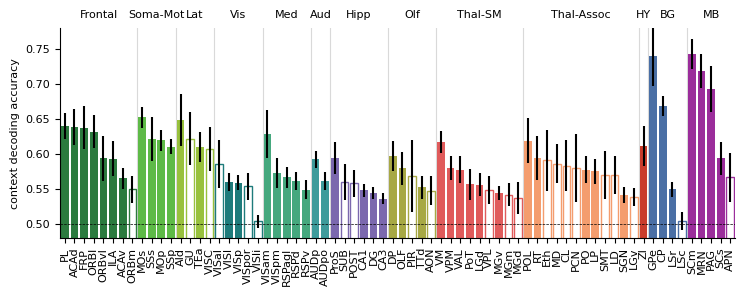

In [15]:
input_data = decoding_baseline_results.copy() #must have session_id and structure columns, and optionally mouse_id and unit_id columns
col_to_plot = 'mean_true' #column in your dataframe you want to plot
col_alias = 'context decoding accuracy' #alias for the column to display in plots
stats_comp_value = 0.5 #set to 0.5 if decoding
test_type = 'ttest' #ttest or wilcoxon
set_ylim=[0.48, 0.78] #set to 'auto' or a specific range
min_n_units_per_session = 10
min_n_sessions_per_mouse = 1
min_n_mice = 3
excl_structure_list = []

decoding_structure_results = plot_utils.get_structure_averages(
    input_data=input_data,
    cols_to_average=[col_to_plot],
    stats_comp_value=stats_comp_value,
    min_n_units_per_session=min_n_units_per_session,
    min_n_sessions_per_mouse=min_n_sessions_per_mouse,
    min_n_mice=min_n_mice,
    test_type=test_type,
    excl_structure_list=excl_structure_list
)

fig = plot_utils.plot_structure_results(
    decoding_structure_results, 
    col_to_plot=col_to_plot, 
    col_alias=col_alias, 
    set_ylim=set_ylim, 
    set_fontsize=8
)

fig.savefig(f"{savepath}\structure_decoding_barplot_avg_by_mouse.png",dpi=300)


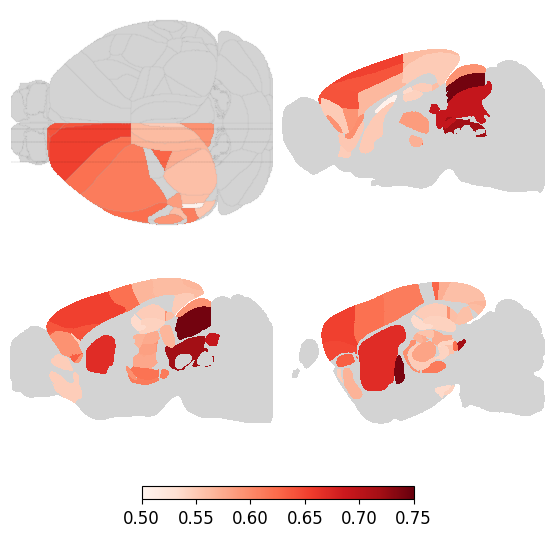

In [16]:
#also make CCF heatmap

chart,x = plot_utils.plot_brain_heatmap(
    regions=decoding_structure_results['structure'],
    values=decoding_structure_results['mean_true_mean'], #mean_true, mean_diff
    sagittal_planes=(-300,-1000,-2000,),
    cmap='Reds',
    clevels=(0.5,0.75),
    annotation_params={
        'fontsize':6,
    },
    plot_2x2=True,
)

plt.savefig(os.path.join(savepath,"decoding_realbrain_heatmap.png"),dpi=600,bbox_inches='tight')

### baseline context encoding results

In [17]:
#glm baseline results
result_prefix = 'v289'
run_id = "1"

def get_wide_table(result_prefix, run_id): 
    return pl.scan_parquet(f"s3://aind-scratch-data/dynamic-routing/encoding/scores/{result_prefix}_{run_id}.parquet",  storage_options={"skip_signature": "true"},).collect()

def add_unit_metrics(unit_df):
    return (
        unit_df.lazy()
                .join(
            pl.scan_parquet('s3://aind-scratch-data/dynamic-routing/cache/nwb_components/v0.0.268/consolidated/units.parquet', storage_options={"skip_signature": "true"})
            .select('unit_id','structure','location','activity_drift','isi_violations_ratio',
                    'presence_ratio', 'amplitude_cutoff','firing_rate', 'decoder_label'),# right table
            on='unit_id',
            how = 'inner',
        ) 
    ).collect()

glm_baseline_results = get_wide_table(result_prefix= result_prefix, run_id = run_id)
glm_baseline_results = add_unit_metrics(glm_baseline_results)

structure_mapping = {
    "ECT1": 'ECT',
    "ECT2/3": 'ECT',
    "ECT6b": 'ECT',
    "ECT5": 'ECT',
    "ECT6a": 'ECT',
    "ECT4": 'ECT',
    'SCop': 'SCs',
    'SCsg': 'SCs',
    'SCzo': 'SCs',
    'SCig': 'SCm',
    'SCiw': 'SCm',
    'SCdg': 'SCm',
    'SCdw': 'SCm',
}

# map SC units to SCs or SCm, also ECT (maybe not necessary?)
glm_baseline_results = glm_baseline_results.with_columns(
    pl.when(pl.col('structure').is_in(structure_mapping.keys()).is_first_distinct().over('unit_id'))
    .then(pl.col('structure').replace(structure_mapping))
    .otherwise(pl.col('structure'))
)

# exclude redundant or general structures
glm_baseline_results = decoding_utils.exclude_structures_from_df(
    glm_baseline_results, exclude_redundant_structures=True, exclude_general_structures=True
).to_pandas()

glm_baseline_results=glm_baseline_results.query(
    'session_id in @dr_session_list and \
    presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.1'
    )
glm_baseline_results['mouse_id']=glm_baseline_results['session_id'].str.split('_').str[0]

In [18]:
glm_baseline_results.columns

Index(['session_id', 'unit_id', 'project', 'cv_test_running', 'cv_test_miss',
       'cv_test_context', 'cv_test_session_time', 'cv_test_correct_reject',
       'cv_test_nose', 'cv_test_jaw', 'cv_test_false_alarm', 'cv_test_ears',
       'cv_test_choice', 'cv_test_whisker_pad', 'cv_test_facial_features',
       'cv_test_pupil', 'cv_test_hit', 'cv_train_running', 'cv_train_miss',
       'cv_train_context', 'cv_train_session_time', 'cv_train_correct_reject',
       'cv_train_nose', 'cv_train_jaw', 'cv_train_false_alarm',
       'cv_train_ears', 'cv_train_choice', 'cv_train_whisker_pad',
       'cv_train_facial_features', 'cv_train_pupil', 'cv_train_hit',
       'drop_score_running', 'drop_score_miss', 'drop_score_context',
       'drop_score_session_time', 'drop_score_correct_reject',
       'drop_score_nose', 'drop_score_jaw', 'drop_score_false_alarm',
       'drop_score_ears', 'drop_score_choice', 'drop_score_whisker_pad',
       'drop_score_facial_features', 'drop_score_pupil', 'drop_

In [ ]:
input_data = glm_baseline_results.copy() #must have session_id and structure columns, and optionally mouse_id and unit_id columns
col_to_plot = 'delta_r2_context' #column in your dataframe you want to plot
col_alias = 'context ΔR²' #alias for the column to display in plots
stats_comp_value = 0.0 #set to 0.5 if decoding
test_type = 'ttest' #ttest or wilcoxon
set_ylim='auto' #set to 'auto' or a specific range
min_n_units_per_session = 10
min_n_sessions_per_mouse = 1
min_n_mice = 3
excl_structure_list = ['EPd']

encoding_structure_results = plot_utils.get_structure_averages(
    input_data=input_data,
    cols_to_average=[col_to_plot],
    stats_comp_value=stats_comp_value,
    min_n_units_per_session=min_n_units_per_session,
    min_n_sessions_per_mouse=min_n_sessions_per_mouse,
    min_n_mice=min_n_mice,
    test_type=test_type,
    excl_structure_list=excl_structure_list
)

fig = plot_utils.plot_structure_results(
    encoding_structure_results, 
    col_to_plot=col_to_plot, 
    col_alias=col_alias, 
    set_ylim=set_ylim, 
    set_fontsize=8
)

fig.savefig(f"{savepath}/structure_encoding_barplot_avg_by_mouse.png",dpi=300)


In [ ]:
#also make CCF heatmap

chart,x = plot_utils.plot_brain_heatmap(
    regions=encoding_structure_results['structure'],
    values=encoding_structure_results['delta_r2_context_mean'],
    sagittal_planes=(-300,-1000,-2000,),
    cmap='Reds',
    clevels=(0,0.010),
    annotation_params={
        'fontsize':6,
    },
    plot_2x2=True,
)


plt.savefig(os.path.join(savepath,"encoding_realbrain_heatmap.png"),dpi=600,bbox_inches='tight')

In [ ]:
# merge encoding and decoding results
merged_structure_results = encoding_structure_results.merge(
    decoding_structure_results,
    on='structure',
    suffixes=('_encoding', '_decoding'),
    how='inner'
)

simplified_structure_by_structure=plot_utils.get_structure_colormap(by_structure=True,by_group=False)

merged_structure_results = merged_structure_results.merge(
    simplified_structure_by_structure,
    on='structure',
    how='left'
)

r,p=stats.pearsonr(
    merged_structure_results['delta_r2_context_mean'],
    merged_structure_results['mean_true_mean']
)

fig,ax=plt.subplots(figsize=(3,3))
ax.scatter(
    merged_structure_results['delta_r2_context_mean'],
    merged_structure_results['mean_true_mean'],
    c=merged_structure_results['structure_color'],
    s=12
)
ax.set_xlabel('Encoding ΔR²')
ax.set_ylabel('Decoding accuracy')
ax.set_title(f'Pearson r = {r:.2f}, p = {p:.2g}')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

fig.savefig(os.path.join(savepath, "encoding_vs_decoding_scatter_plot.png"),dpi=300)